# Imputation and DP: donor copying vs. a model you can compose with

The last of Drechsler & Bailie's five complications (Section 6) is item
nonresponse: most surveys have some questions individual respondents skip,
and agencies routinely fill these gaps by imputation before releasing data,
since analyzing only the fully-observed cases would bias results whenever
missingness isn't completely random.

Imputation models are fit on the observed data, so — like the weighting
adjustments in
[`weighting_adjustments.ipynb`](weighting_adjustments.ipynb) — they're data
dependent. Das, Drechsler, Merrill & Merrill (2022) show this can be much
worse for imputation than for weighting: for *hot-deck* imputation (filling
each missing value with a copy of a similar respondent's — a "donor"), the
worst-case sensitivity grows *linearly in the number of imputed records*,
because one donor's value can be copied into arbitrarily many recipients.

The paper also describes the fix: if the imputation model can be written as

```
D_imp^(i) ~ m(D_obs^(i), theta_hat)
```

— record `i`'s imputed value depends only on record `i`'s *own* observed
data plus a shared parameter `theta_hat` — and `theta_hat` is estimated with
any suitable DP mechanism at cost `eps1`, then the whole pipeline composes
simply: total privacy loss is `eps1 + eps2` for any `eps2`-DP mechanism
applied afterward. This holds for parametric imputation (e.g. regression);
it does *not* hold for hot-deck, which is exactly why hot-deck is the
problem case.

This notebook builds both. The DP-congenial model turns out to be a natural
fit for `noisyvalue`'s dependent noise sources — the same mechanism the
library already uses for hierarchical models.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import opendp.prelude as dp

dp.enable_features("contrib", "honest-but-curious")

from noisyvalue import opendp as nvdp
from noisyvalue import NoisyFloat, plot_posterior, sample_noisy_values

## Hot-deck imputation: one donor, many recipients

`500` respondents, `y` bounded to `[0, 1]`, `80%` item nonresponse (kept
high on purpose, so donor pools are thin and the effect is stark). Missing
values are imputed by drawing a random donor with the same `x`-bin (a
standard, simple hot-deck scheme).

In [2]:
rng = np.random.default_rng(0)

n, R = 500, 1.0
x = rng.normal(0, 1, n)
y_true = np.clip(0.5 + 0.15 * x + rng.normal(0, 0.2, n), 0.0, 1.0)
missing = rng.random(n) < 0.8
observed = ~missing

n_bins = 3
edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))
edges[0] -= 1e-6
bins = np.clip(np.digitize(x, edges) - 1, 0, n_bins - 1)

print(f"observed: {observed.sum()}, missing: {missing.sum()}")


def hotdeck_impute(y_vals, obs_mask, seed):
    donor_rng = np.random.default_rng(seed)
    y_imp = y_vals.copy()
    donor_of = np.full(n, -1)
    for b in range(n_bins):
        donors = np.where((bins == b) & obs_mask)[0]
        recipients = np.where((bins == b) & ~obs_mask)[0]
        if len(donors) == 0 or len(recipients) == 0:
            continue
        chosen = donor_rng.choice(donors, size=len(recipients), replace=True)
        y_imp[recipients] = y_vals[chosen]
        donor_of[recipients] = chosen
    return y_imp, donor_of


completed, donor_of = hotdeck_impute(y_true, observed, seed=1)
print(f"completed total: {completed.sum():.2f}")

observed: 106, missing: 394
completed total: 232.97


Copying is deterministic given the donor draws, so the sensitivity from
perturbing one donor's value is exact, not just empirically estimated: it's
`(number of recipients who copied that donor) * R`. Every observed unit's
"fan-out" — how many recipients depend on it — is a fixed, computable
number:

busiest donor serves 8 recipients
perturbing that one donor's value by up to R=1.0 moves the completed total by up to 8.0 -- 8x the naive single-record bound


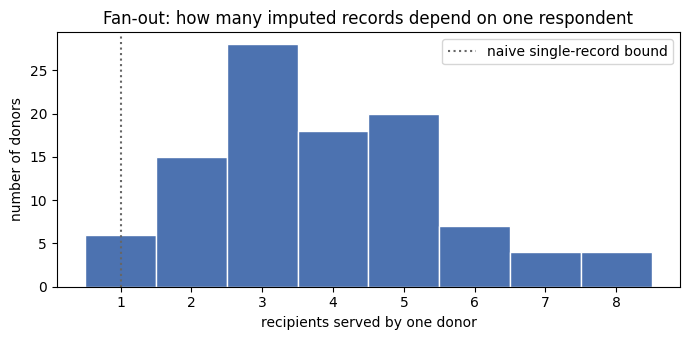

In [3]:
fan_out = np.bincount(donor_of[donor_of >= 0], minlength=n)
busiest_donor = fan_out.argmax()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(fan_out[fan_out > 0], bins=range(1, fan_out.max() + 2), align="left",
        color="#4C72B0", edgecolor="white")
ax.axvline(1, color="0.4", linestyle=":", label="naive single-record bound")
ax.set_xlabel("recipients served by one donor")
ax.set_ylabel("number of donors")
ax.set_title("Fan-out: how many imputed records depend on one respondent")
ax.legend()
plt.tight_layout()

print(f"busiest donor serves {fan_out[busiest_donor]} recipients")
print(f"perturbing that one donor's value by up to R={R} moves the "
      f"completed total by up to {fan_out[busiest_donor] * R:.1f} -- "
      f"{fan_out[busiest_donor]}x the naive single-record bound")

In [4]:
# Confirm it directly: flip the busiest donor's value and re-run the identical donor draws.
y_perturbed = y_true.copy()
y_perturbed[busiest_donor] = 1.0 - y_true[busiest_donor]
completed_perturbed, _ = hotdeck_impute(y_perturbed, observed, seed=1)

print(f"completed total before: {completed.sum():.2f}")
print(f"completed total after:  {completed_perturbed.sum():.2f}")
print(f"observed change:        {completed_perturbed.sum() - completed.sum():.2f}")

completed total before: 232.97
completed total after:  230.73
observed change:        -2.24


Bounding this in general means bounding the largest possible fan-out across
*any* dataset, which for hot-deck has no fixed limit short of the number of
missing records itself — exactly Das et al.'s "worst case, the sensitivity
increases linearly with the number of imputed observations." A statistical
agency publishing a pre-imputed file for outside researchers to analyze
can't get around this by being clever at the analysis stage either: it
doesn't know in advance which statistics will be computed from the file.

## A DP-congenial alternative: impute from a shared, DP-released parameter

Instead of copying a donor, model `E[y|x]` directly and impute from that
model. Concretely: bin respondents by `x` (as before, but the bins are
public — they only use `x`, which has no missingness), release each bin's
*mean* of `y` under DP, and impute each missing value as a draw from
`Normal(bin_mean, sigma)`.

Crucially, `bin_mean` is estimated **once**, from the observed data, with a
fixed DP budget `eps1` — it does not get re-estimated per imputed record.
Given that shared, already-protected parameter, each missing record's
imputed value depends only on its own bin membership (public, from `x`) and
fresh independent noise: exactly the `D_imp^(i) ~ m(D_obs^(i), theta_hat)`
form the paper requires.

In [5]:
eps1 = 1.0
eps_per_bin = eps1 / n_bins


def dp_bin_mean(b):
    values = y_true[(bins == b) & observed].tolist()
    n_obs_b = len(values)   # bin membership and its count are public (from x, not y)
    trans = dp.t.make_sum(
        dp.vector_domain(dp.atom_domain(bounds=(0.0, R), nan=False)),
        dp.symmetric_distance())
    scale = R / eps_per_bin
    meas = trans >> nvdp.make_gaussian(trans.output_domain, trans.output_metric, scale)
    return meas(values) / n_obs_b


bin_means = [dp_bin_mean(b) for b in range(n_bins)]
for b, m in enumerate(bin_means):
    true_mean = y_true[(bins == b) & observed].mean()
    print(f"bin {b}: DP mean {m} (true observed-data mean {true_mean:.3f})")

bin 0: DP mean ~0.3233976378020883 (true observed-data mean 0.328)
bin 1: DP mean ~0.6426098002940344 (true observed-data mean 0.465)
bin 2: DP mean ~0.6347014076280859 (true observed-data mean 0.643)


`bin_means[b]` is a `NoisyFloat` — a live node in the graph, not a number.
Building each imputed value with `NoisyFloat.gaussian(loc=..., scale=...)`
using that node as `loc` makes it a *dependent* noise source: the library
already supports exactly this for hierarchical models (a noise source whose
parameters reference another node's symbol), so nothing new is needed here.

In [6]:
sigma_impute = 0.2   # residual scale for the imputation model

imputed = {
    i: NoisyFloat.gaussian(loc=bin_means[bins[i]], scale=sigma_impute,
                           obs=float(bin_means[bins[i]]))
    for i in np.where(missing)[0]
}

completed_total = sum(imputed.values(), start=NoisyFloat.lift(float(y_true[observed].sum())))
print(f"completed-total point estimate: {completed_total}")

draws = completed_total.sample(n=6000, rng=np.random.default_rng(0))
print(f"posterior mean {draws.draws.mean():.1f}, std {draws.draws.std():.1f}")

completed-total point estimate: ~261.471815289556


posterior mean 261.7, std 20.1


`plot_posterior` renders posteriors by deterministic quadrature over
*independent* noise nodes; it doesn't yet walk dependent (hierarchical)
nodes like the `loc=bin_means[...]` construction above, so it isn't the
right tool for this particular value — we use the sampler's draws instead,
which handle dependent nodes natively (that's exactly what
`NoisyValueSampler`'s topological pass over law nodes is for):

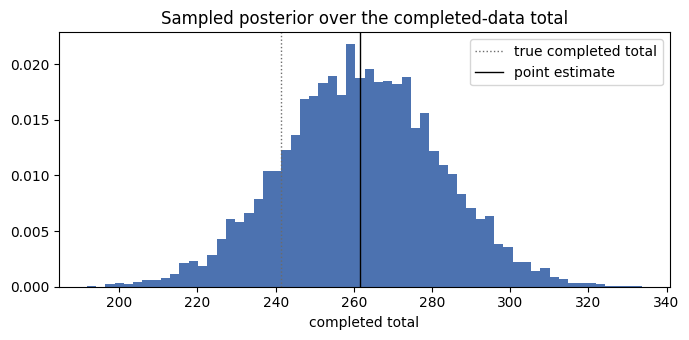

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(draws.draws, bins=60, color="#4C72B0", density=True)
ax.axvline(y_true.sum(), color="#6b6b6b", linewidth=1, linestyle=":", label="true completed total")
ax.axvline(float(completed_total), color="black", linewidth=1, label="point estimate")
ax.legend()
ax.set_xlabel("completed total")
ax.set_title("Sampled posterior over the completed-data total")
plt.tight_layout()

Two imputed values that share a bin aren't independent — they inherit the
same DP-released `bin_mean` uncertainty, on top of their own independent
residual draws. Joint sampling shows this directly:

In [8]:
same_bin = [i for i in imputed if bins[i] == bins[next(iter(imputed))]][:2]
draw_a, draw_b = sample_noisy_values(imputed[same_bin[0]], imputed[same_bin[1]],
                                     n=6000, rng=np.random.default_rng(0))
corr = np.corrcoef(draw_a.draws, draw_b.draws)[0, 1]
print(f"correlation between two imputed values sharing a bin: {corr:.3f}")
print("(nonzero, because they share theta_hat's uncertainty; not larger, "
      "because each unit's own residual noise still dominates)")

correlation between two imputed values sharing a bin: 0.181
(nonzero, because they share theta_hat's uncertainty; not larger, because each unit's own residual noise still dominates)


## Composition, for real

Because each imputed value depends on no other unit's data (only on the
already-DP-protected `theta_hat` and its own fresh noise), *any* further
`eps2`-DP release computed from the completed file composes with the
imputation step by simple addition — `eps1 + eps2` — regardless of what
that further release computes. Concretely: draw one realized completed file
(what the agency's actual output table would contain), then release its
total under an independent Gaussian mechanism:

In [9]:
completed_file = y_true.copy()
draw_rng = np.random.default_rng(2)
for i in np.where(missing)[0]:
    completed_file[i] = np.clip(draw_rng.normal(float(bin_means[bins[i]]), sigma_impute), 0.0, 1.0)

trans1 = dp.t.make_sum(
    dp.vector_domain(dp.atom_domain(bounds=(0.0, R), nan=False)), dp.symmetric_distance())
meas1 = trans1 >> dp.m.make_gaussian(trans1.output_domain, trans1.output_metric, R / eps_per_bin)
rho1_total = meas1.map(1) * n_bins   # n_bins independent releases, each this sensitivity/scale

eps2 = 1.0
trans2 = dp.t.make_sum(
    dp.vector_domain(dp.atom_domain(bounds=(0.0, R), nan=False)), dp.symmetric_distance())
scale2 = R / eps2
meas2 = trans2 >> nvdp.make_gaussian(trans2.output_domain, trans2.output_metric, scale2)
release2 = meas2(completed_file.tolist())

print(f"rho spent imputing (bin-mean releases): {rho1_total:.3f}")
print(f"rho spent on the further completed-data release: {meas2.map(1):.3f}")
print(f"total rho spent: {rho1_total + meas2.map(1):.3f}  (= rho1 + rho2, plain composition)")
print(f"further release: {release2}")

rho spent imputing (bin-mean releases): 0.167
rho spent on the further completed-data release: 0.500
total rho spent: 0.667  (= rho1 + rho2, plain composition)
further release: ~259.3274436937917


No worst-case blow-up to account for, and no need to reason about how many
other records a perturbation might touch — because, by construction, it
touches none. That's the entire advantage over hot-deck: not less noise on
any single release, but a privacy *accounting* that stays simple no matter
how the completed file is used afterward.